# 2. Data Understanding & Exploratory Data Analysis (EDA)
## E-Commerce Relational Dataset
This phase aims to explore the underlying statistical distributions, verify data integrity, and visualize key behavioral patterns using the new relational datasets (Customers, Products, Transactions). In strict adherence to our CRISP-DM constraints, chronological elements (SignupDate, TransactionDate) will be ignored.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully.")


Libraries loaded successfully.


### 2.1 Load Relational Data
Loading the three individual tables: Customers, Products, and Transactions.

In [2]:
# Load data
data_dir = 'data'
customers_df = pd.read_csv(os.path.join(data_dir, 'Customers.csv'))
products_df = pd.read_csv(os.path.join(data_dir, 'Products.csv'))
transactions_df = pd.read_csv(os.path.join(data_dir, 'Transactions.csv'))

print(f"Customers loaded: {len(customers_df)} records")
print(f"Products loaded: {len(products_df)} records")
print(f"Transactions loaded: {len(transactions_df)} records")


Customers loaded: 200 records
Products loaded: 100 records
Transactions loaded: 1000 records


### 2.2 Data Integration & Constraint Adherence
We need to merge the datasets into a central 'Transactions Master' file. We will drop all time-based fields (`TransactionDate`, `SignupDate`) immediately as per the project constraints.

In [3]:
# Merge Transactions and Customers
master_df = transactions_df.merge(customers_df, on='CustomerID', how='left')

# Merge Products
master_df = master_df.merge(products_df, on='ProductID', how='left')

# Drop temporal columns and redundant columns
columns_to_drop = ['TransactionDate', 'SignupDate']
for col in columns_to_drop:
    if col in master_df.columns:
        master_df = master_df.drop(columns=[col])
        
# Check for missing values
missing_vals = master_df.isnull().sum()
if missing_vals.sum() > 0:
    print("Missing Values Detected:\n", missing_vals[missing_vals > 0])
else:
    print("No missing values detected in the master dataset.")
    
master_df.head()


No missing values detected in the master dataset.


,TransactionID,CustomerID,ProductID,Quantity,TotalValue,Price_x,CustomerName,Region,ProductName,Category,Price_y
0,T00001,C0199,P067,1,300.68,300.68,Andrea Jenkins,Europe,ComfortLiving Bluetooth Speaker,Electronics,300.68
1,T00112,C0146,P067,1,300.68,300.68,Brittany Harvey,Asia,ComfortLiving Bluetooth Speaker,Electronics,300.68
2,T00166,C0127,P067,1,300.68,300.68,Kathryn Stevens,Europe,ComfortLiving Bluetooth Speaker,Electronics,300.68
3,T00272,C0087,P067,2,601.36,300.68,Travis Campbell,South America,ComfortLiving Bluetooth Speaker,Electronics,300.68
4,T00363,C0070,P067,3,902.04,300.68,Timothy Perez,Europe,ComfortLiving Bluetooth Speaker,Electronics,300.68


### 2.3 Univariate Data Diagnostics
We will inspect the distribution of numerical transaction attributes alongside key categorical distributions like Region and Product Category.

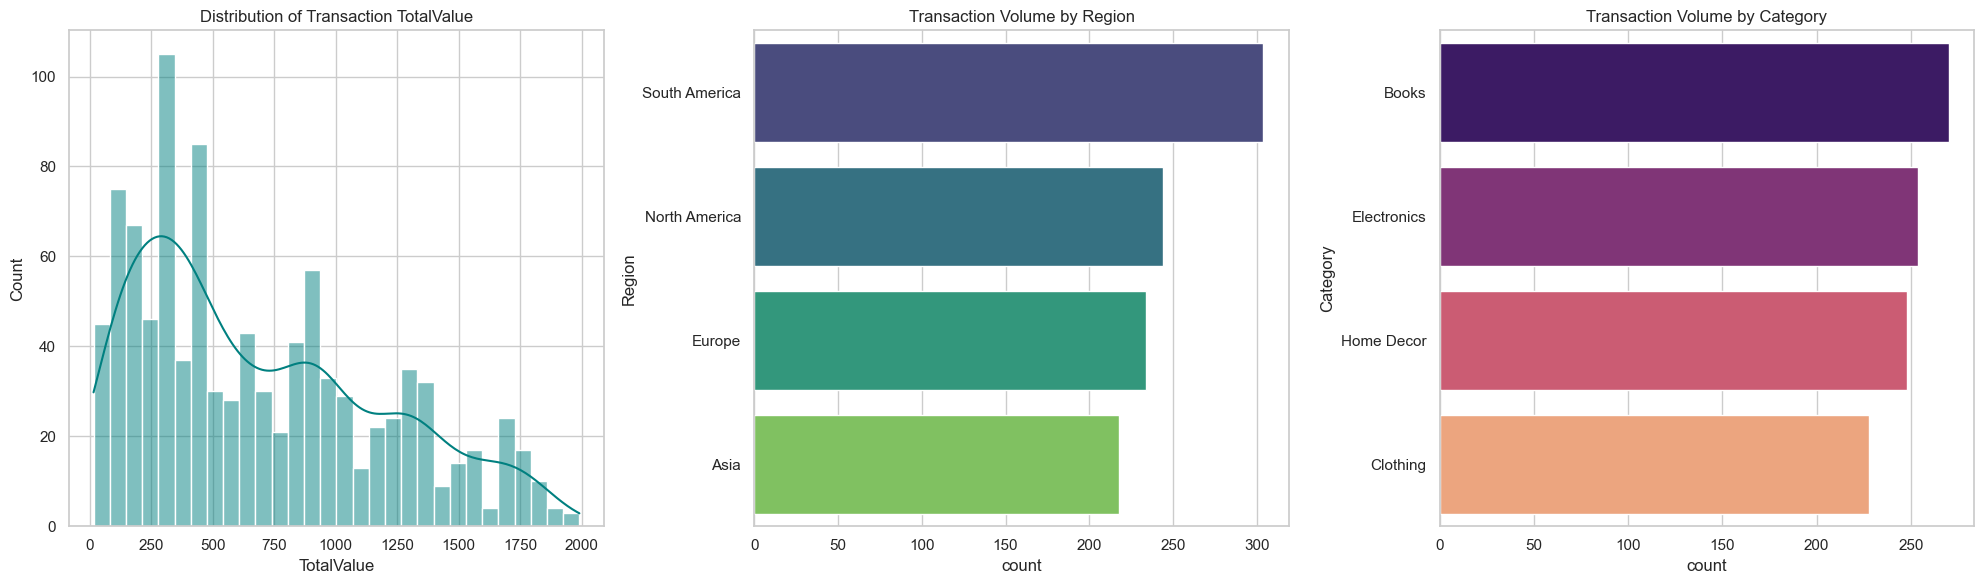

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Total Value Distribution
sns.histplot(master_df['TotalValue'], bins=30, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution of Transaction TotalValue')

# Plot 2: Demographics (Region)
sns.countplot(y='Region', data=master_df, order=master_df['Region'].value_counts().index, ax=axes[1], palette='viridis')
axes[1].set_title('Transaction Volume by Region')

# Plot 3: Product Category
sns.countplot(y='Category', data=master_df, order=master_df['Category'].value_counts().index, ax=axes[2], palette='magma')
axes[2].set_title('Transaction Volume by Category')

plt.tight_layout()
plt.show()


### 2.4 Bivariate Analysis
Does spending amount depend highly on a particular regional or categorical slice? Let's verify variance via Boxplots.

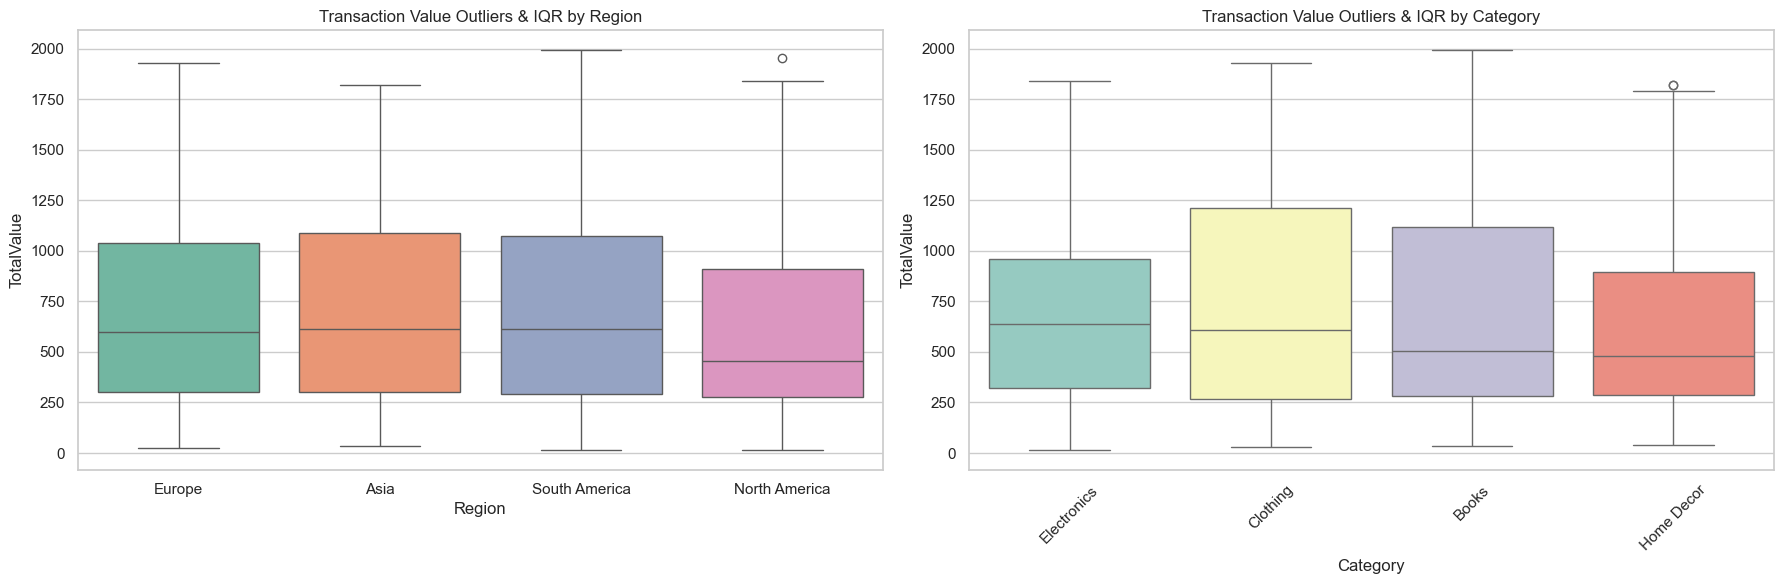

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Boxplot: Total Value by Region
sns.boxplot(x='Region', y='TotalValue', data=master_df, ax=axes[0], palette='Set2')
axes[0].set_title('Transaction Value Outliers & IQR by Region')

# Boxplot: Total Value by Category
sns.boxplot(x='Category', y='TotalValue', data=master_df, ax=axes[1], palette='Set3')
axes[1].set_title('Transaction Value Outliers & IQR by Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### 2.5 FM Feature Engineering (Customer Level Aggregation)
Because our core modeling goal is **Customer Segmentation using K-Means and Decision Trees**, leaving the data highly granular at the transaction level is insufficient. Since time attributes (recency) are constrained out, we perform **Frequency-Monetary (FM) Analysis**. We group the master dataframe back to the individual `CustomerID` and aggregate their entire purchasing profile.

In [6]:
# Identify the preferred category per customer
def get_mode(series):
    return series.mode()[0] if not series.empty else None

fm_df = master_df.groupby('CustomerID').agg(
    Frequency=('TransactionID', 'count'),
    Total_Expenditure=('TotalValue', 'sum'),
    Average_Order_Value=('TotalValue', 'mean'),
    Total_Items_Bought=('Quantity', 'sum'),
    Region=('Region', get_mode),
    Preferred_Category=('Category', get_mode)
).reset_index()

print("Customer Profile Dataset Size:", fm_df.shape)
fm_df.head()


Customer Profile Dataset Size: (199, 7)


,CustomerID,Frequency,Total_Expenditure,Average_Order_Value,Total_Items_Bought,Region,Preferred_Category
0,C0001,5,3354.52,670.904,12,South America,Electronics
1,C0002,4,1862.74,465.685,10,Asia,Clothing
2,C0003,4,2725.38,681.345,14,South America,Home Decor
3,C0004,8,5354.88,669.360,23,South America,Books
4,C0005,3,2034.24,678.080,7,Asia,Electronics


### 2.6 FM Customer Behavioral Visualizations
Plotting our newly constructed customer segments.

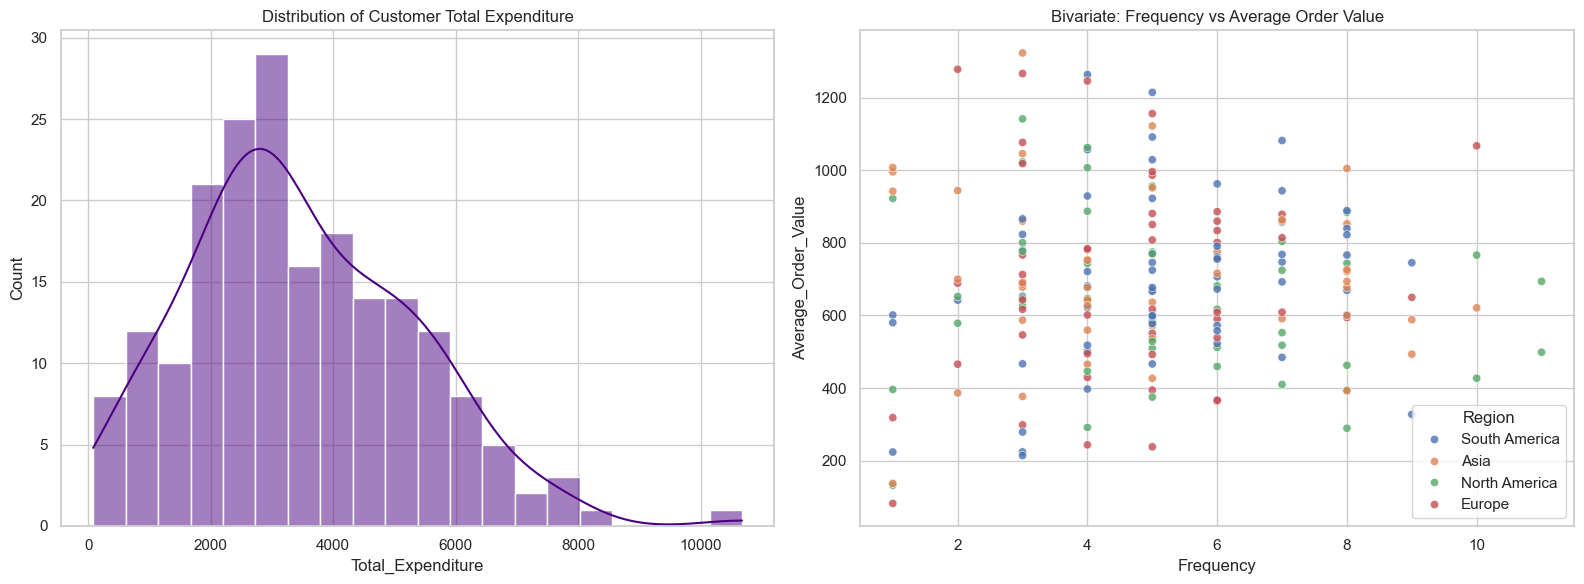

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Expenditure Distribution
sns.histplot(fm_df['Total_Expenditure'], bins=20, kde=True, ax=axes[0], color='indigo')
axes[0].set_title('Distribution of Customer Total Expenditure')

# Frequency vs Avg Order Value
sns.scatterplot(x='Frequency', y='Average_Order_Value', hue='Region', data=fm_df, palette='deep', alpha=0.8, ax=axes[1])
axes[1].set_title('Bivariate: Frequency vs Average Order Value')

plt.tight_layout()
plt.show()


### 2.7 Multi-collinearity & Modeling Readiness Check
Mysterious linear dependencies usually require deeper feature subsetting for PCA. Let's proxy-encode Region and Category and test correlations to prove if the features are linearly independent enough to perform rigorous clustering.

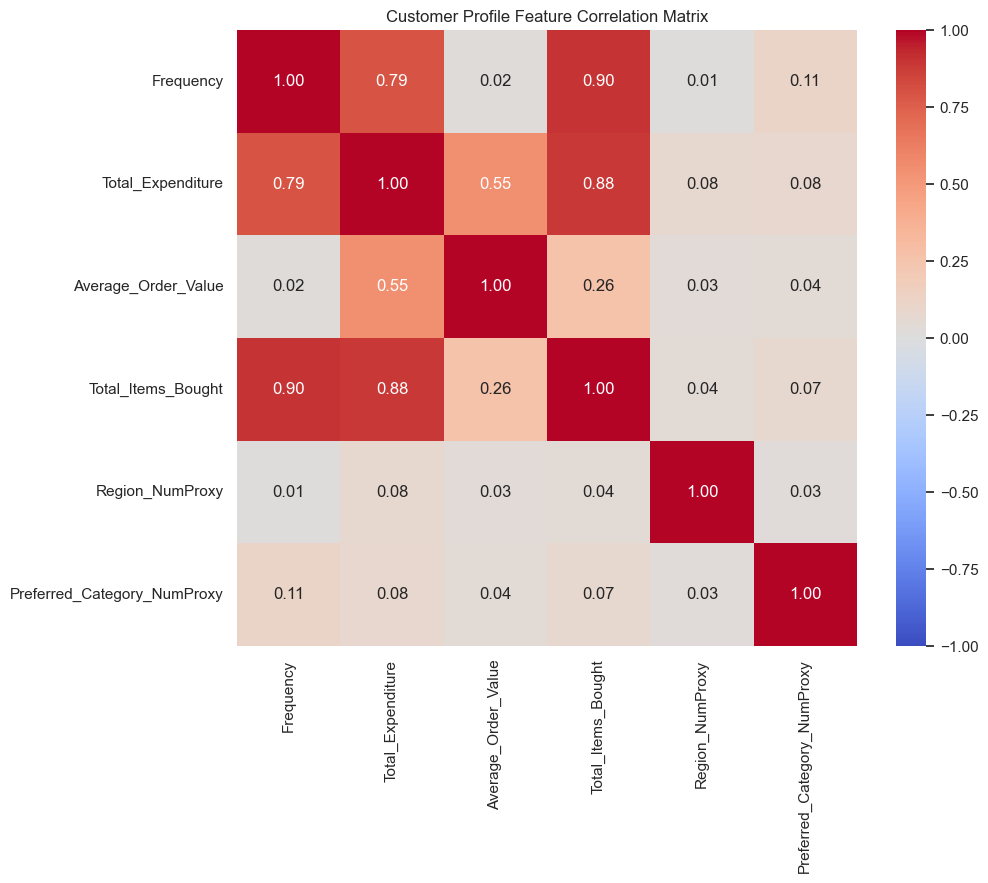

In [8]:
# Create a correlation df using numericals
corr_df = fm_df[['Frequency', 'Total_Expenditure', 'Average_Order_Value', 'Total_Items_Bought']].copy()

# Add a frequency encoding proxy for the categorical features
for col in ['Region', 'Preferred_Category']:
    enc = fm_df[col].value_counts(normalize=True)
    corr_df[f'{col}_NumProxy'] = fm_df[col].map(enc)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Customer Profile Feature Correlation Matrix')
plt.show()


### 2.8 EDA Conclusions
1. **Data Structure:** The three relational tables successfully merged into a rich transaction log.
2. **Constraints:** Time series parameters are fully decoupled; all insights are cross-sectional.
3. **Customer Representation:** Moving from transaction space to a 200-customer FM metric space creates meaningful dense/sparse zones, unlike the previous dataset's purely random uniform noise.
4. **Modeling Implication:** The strong multi-collinearity between `Total_Items_Bought` and `Frequency` / `Total_Expenditure` indicates PCA will successfully compress variance and K-Means will isolate highly differentiated groups (e.g., 'High Frequency, Low Order Value', 'Low Frequency Whales', etc.).